The problem
$$
\frac{\partial u}{\partial t} + \frac{\partial f(u)}{\partial x} = 0 \\
u(t, 0) = u(t, 1) \\
u(0, \cdot) \sim \mathcal N(0, k) \\
k(x, x') = \sigma^2\exp(-\frac{1 - \cos(2\pi(x - x'))}{L^2}) \\
u = \text{conserved quantity} \\
x = \text{space} \\
t = \text{time} \\
f = \text{flux function} \\
k = \text{covariance kernel} \\
\sigma = \text{standard deviation} \\
L = \text{correlation length}
$$

The model trains on cubic polynomial flux functions
$$
f(u) = au^3 + bu^2 + cu \\
a, b, c \sim U([-1, 1])
$$

The model learns the forward operator
$$
F_{f, \tau}[u(t, \cdot)] = u(\tau, \cdot), \quad u(t, x) \mapsto u(t + \tau, x) \\
R_{f, \tau}[u] = \set{v \mid F_{f, \tau}[v] = u}
$$

The model tests on nonpolynomial flux functions
$$
\sin(u) - \cos(u) \\
\tanh(u)
$$

In [192]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Annotated, Any, Sequence
import yaml
import jax
import jax.numpy as jnp
import jax.random as jr

In [193]:
# randomness
seed = 42
key = jr.key(seed)

In [194]:
# define spatial domain
min_space = -1
max_space = 1
nx = 100
x = jnp.linspace(min_space, max_space, nx, endpoint=False)
dx = (max_space - min_space) / nx

In [195]:
# define temporal domain
min_time = 0
max_time = 0.5
nt = 500
t = jnp.linspace(min_time, max_time, nt, endpoint=True)

In [196]:
def covariance(
    x: Annotated[jax.Array, "(nx,)"],
    *,
    sigma: float = 1.0,
    ell: float = 1.0,
    eps: float = 1e-5,
) -> Annotated[jax.Array, "(nx, nx)"]:
    """
    compute the covariance between u(x_i) and u(x_j)
    symmetric: K = K^T
    positive semidefinite: x^T * K * x >= 0

    parameters
    ----------
    x
        spatial coordinate array
    sigma
        standard deviation
    ell
        speed of correlation decay
    eps
        safety factor for numerical stability

    returns
    -------
    L
        lower triangular covariance matrix
    """
    distance = x[:, None] - x[None, :]

    # periodic gaussian kernel
    K = sigma**2 * jnp.exp(-1 * (1 - jnp.cos(2 * jnp.pi * distance)) / ell ** 2)

    # symmetrize covariance matrix
    K = 0.5 * (K + K.T)

    # regularize covariance matrix
    I = jnp.eye(K.shape[0])
    K += eps * I

    # factorize covariance matrix
    L = jnp.linalg.cholesky(K)
    return L
L = covariance(x, sigma=1, ell=1)

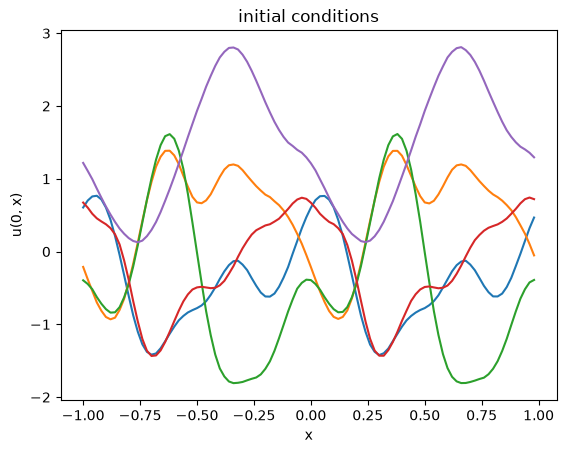

In [197]:
def initialize(
    x: Annotated[jax.Array, "(nx,)"],
    L: Annotated[jax.Array, "(nx, nx)"],
    key: Annotated[jax.Array, "() | (2,)"],
    *,
    n: int,
) -> Annotated[jax.Array, "(n, nx)"]:
    """
    generate initial conditions

    parameters
    ----------
    x
        spatial coordinate array
    L
        lower triangular covariance matrix
    key
        random number generator
    n
        number of initial conditions
    
    returns
    -------
    u_0
        initial conditions
    """
    nx = len(x)
    u_0 = np.empty((n, nx))
    for i in range(n):
        key, subkey = jr.split(key)
        z = jr.normal(subkey, (nx,))
        u_0[i] = jnp.matmul(L, z)
    u_0 = jnp.array(u_0)
    return u_0
u_0 = initialize(x, L, key, n=5)

for i in range(len(u_0)):
    plt.plot(x, u_0[i])
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("initial conditions")
plt.show()

In [198]:
def sample_coeff(
    domain: Annotated[Sequence[float], "(2,)"],
    key: Annotated[jax.Array, "() | (2,)"],
    *,
    n: int,
) -> Annotated[jax.Array, "(n,)"]:
    """
    sample coefficients from uniform probability distribution

    parameters
    ----------
    domain
        minimum and maximum value of coefficients
    key
        random number generator
    n
        number of coefficients
    
    returns
    -------
    coeffs
        coefficients
    """
    return jr.uniform(key, (n,), minval=domain[0], maxval=domain[1])
coeffs = sample_coeff([-1, 1], key, n=3)

In [199]:
def flux(
    u: Annotated[jax.Array, "() | (nx,)"],
    coeffs: Annotated[jax.Array, "(3,)"],
) -> Annotated[jax.Array, "() | (nx,)"]:
    """
    compute flux

    parameters
    ----------
    u
        solution
    coeffs
        coefficients

    returns
    -------
    f
        flux
    """
    return coeffs[0] * u ** 3 + coeffs[1] * u ** 2 + coeffs[2] * u


In [200]:
def speed(
    u: Annotated[jax.Array, "() | (nx,)"],
    coeffs: Annotated[jax.Array, "(3,)"],
) -> Annotated[jax.Array, "() | (nx,)"]:
    """
    compute speed

    parameters
    ----------
    u
        solution
    coeffs
        coefficients
    
    returns
    ------
    speed
        speed
    """
    J = jax.jacrev(lambda value: flux(value, coeffs))(u)
    return jnp.abs(J)
sol_speed = speed(u_0[0], coeffs)

def max_speed(
    speed: Annotated[jax.Array, "() | (nx,)"],
    *,
    eps: float = 1e-8,
) -> Annotated[jax.Array, "()"]:
    """
    compute max speed

    parameters
    ----------
    speed
        rate of change of position
    eps
        safety factor for numerical stability
    
    returns
    ------
    max_speed
        maximum rate of change of position
    """
    max_speed = jnp.max(speed)
    return jnp.maximum(max_speed, eps)
sol_max_speed = max_speed(sol_speed)

def time_step(
    x: Annotated[jax.Array, "(nx,)"],
    dx: float,
    max_speed: Annotated[jax.Array, "()"],
    *,
    cfl: float = 0.5,
) -> Annotated[jax.Array, "()"]:
    """
    compute time step

    parameters
    ----------
    max_speed
        maximum rate of change of position
    dx
        grid spacing
    cfl
        safety factor for limiting the size of time step (courant-friedrachs-lewy)
    
    returns
    ------
    dt
        time step
    """
    return cfl * dx / max_speed
dt = time_step(x, dx, sol_max_speed)

In [201]:
def neighbor(
    u: Annotated[jax.Array, "(nx,)"],
    *,
    i: int,
    n: int,
) -> tuple[
    Annotated[jax.Array, "()"],
    Annotated[jax.Array, "()"],
]:
    """
    compute solution at neighboring spatial coordinate

    parameters
    ----------
    u
        solution
    i
        index of center solution
    n
        number of neighbors
    
    returns
    ------
    before_sol
        solution before center solution
    after_sol
        solution after center solution
    """
    before_index = (i - n) % len(u)
    after_index = (i + n) % len(u)
    before_sol = u[before_index]
    after_sol = u[after_index]
    return before_sol, after_sol


In [202]:
def numerical_flux(
    u: Annotated[jax.Array, "(nx,)"],
    coeffs: Annotated[jax.Array, "(3,)"],
) -> Annotated[jax.Array, "(nx,)"]:
    """
    compute numerical flux

    parameters
    ----------
    u
        solution
    coeffs
        coefficients

    returns
    -------
    num_flux
        numerical flux
    """
    ORDER = 5  # 5th order WENO
    CENTER = 2  # index of central solution

    num_flux = np.empty(u.shape)
    for i in range(len(u)):

        def create_stencil(
            u: Annotated[jax.Array, "(nx,)"],
            *,
            i: int,
            side: str,
        ) -> tuple[
            Annotated[jax.Array, "(3,)"],
            Annotated[jax.Array, "(3,)"],
            Annotated[jax.Array, "(3,)"],
        ]:
            """
            choose spatial stencil for approximating solution at cell interface \\
            left = {i-2, i-1, i, i+1, i+2} \\
            right = {i+3, i+2, i+1, i, i-1}
            """
            if side == "right":
                i += 1
            stencil = np.empty((ORDER,))
            for n in range(ORDER - CENTER):
                before, after = neighbor(u, i=i, n=n)
                stencil[CENTER - n] = before
                stencil[CENTER + n] = after
            if side == "right":
                stencil = jnp.flip(stencil)
            s0 = jnp.array([stencil[0], stencil[1], stencil[2]])
            s1 = jnp.array([stencil[1], stencil[2], stencil[3]])
            s2 = jnp.array([stencil[2], stencil[3], stencil[4]])
            return s0, s1, s2

        left_s0, left_s1, left_s2 = create_stencil(u, i=i, side="left")
        right_s0, right_s1, right_s2 = create_stencil(u, i=i, side="right")

        def smooth_stencil(
            s0: Annotated[jax.Array, "(3,)"],
            s1: Annotated[jax.Array, "(3,)"],
            s2: Annotated[jax.Array, "(3,)"],
        ) -> tuple[
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
        ]:
            """
            compute smoothness of stencil
            """
            beta0 = 13 / 12 * (s0[0] - 2 * s0[1] + s0[2]) ** 2 + 1 / 4 * (
                s0[0] - 4 * s0[1] + 3 * s0[2]
            ) ** 2
            beta1 = 13 / 12 * (s1[0] - 2 * s1[1] + s1[2]) ** 2 + 1 / 4 * (
                s1[0] - s1[2]
            ) ** 2
            beta2 = 13 / 12 * (s2[0] - 2 * s2[1] + s2[2]) ** 2 + 1 / 4 * (
                3 * s2[0] - 4 * s2[1] + s2[2]
            ) ** 2
            return beta0, beta1, beta2

        left_beta0, left_beta1, left_beta2 = smooth_stencil(left_s0, left_s1, left_s2)
        right_beta0, right_beta1, right_beta2 = smooth_stencil(right_s0, right_s1, right_s2)

        def weight_stencil(
            beta0: Annotated[jax.Array, "()"],
            beta1: Annotated[jax.Array, "()"],
            beta2: Annotated[jax.Array, "()"],
            *,
            eps: float = 1e-6,
        ) -> tuple[
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
        ]:
            """
            if smooth stencil then large weight \\
            if rough stencil then small weight
            """
            alpha0 = 1 / 10 / (eps + beta0) ** 2
            alpha1 = 6 / 10 / (eps + beta1) ** 2
            alpha2 = 3 / 10 / (eps + beta2) ** 2
            return alpha0, alpha1, alpha2

        left_alpha0, left_alpha1, left_alpha2 = weight_stencil(left_beta0, left_beta1, left_beta2)
        right_alpha0, right_alpha1, right_alpha2 = weight_stencil(right_beta0, right_beta1, right_beta2)

        def norm_weight(
            alpha0: Annotated[jax.Array, "()"],
            alpha1: Annotated[jax.Array, "()"],
            alpha2: Annotated[jax.Array, "()"],
        ) -> tuple[
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
        ]:
            """
            normalize stencil weight
            """
            omega0 = alpha0 / (alpha0 + alpha1 + alpha2)
            omega1 = alpha1 / (alpha0 + alpha1 + alpha2)
            omega2 = alpha2 / (alpha0 + alpha1 + alpha2)
            return omega0, omega1, omega2

        left_omega0, left_omega1, left_omega2 = norm_weight(left_alpha0, left_alpha1, left_alpha2)
        right_omega0, right_omega1, right_omega2 = norm_weight(
            right_alpha0, right_alpha1, right_alpha2
        )

        def approx_sol(
            s0: Annotated[jax.Array, "(3,)"],
            s1: Annotated[jax.Array, "(3,)"],
            s2: Annotated[jax.Array, "(3,)"],
        ) -> tuple[
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
            Annotated[jax.Array, "()"],
        ]:
            """
            approximate solution at cell interface using Lagrange interpolation \\
            q \\approx u(x_{i+0.5})
            """
            q0 = 1 / 3 * s0[0] - 7 / 6 * s0[1] + 11 / 6 * s0[2]
            q1 = -1 / 6 * s1[0] + 5 / 6 * s1[1] + 1 / 3 * s1[2]
            q2 = 1 / 3 * s2[0] + 5 / 6 * s2[1] - 1 / 6 * s2[2]
            return q0, q1, q2

        left_q0, left_q1, left_q2 = approx_sol(left_s0, left_s1, left_s2)
        right_q0, right_q1, right_q2 = approx_sol(right_s0, right_s1, right_s2)

        # reconstruct solution
        """
        WENO5 (Weighted Essentially Non-Oscillatory fifth-order) reconstructs high-order estimates of the solution at cell interfaces by adaptively combining several lower-order stencils, assigning larger weights to smooth stencils and smaller weights to stencils containing discontinuities. This produces fifth-order accuracy in smooth parts of the solution while preventing the spurious oscillations that standard high-order methods generate near shocks and other sharp gradients.
        """
        left_sol = left_q0 * left_omega0 + left_q1 * left_omega1 + left_q2 * left_omega2
        right_sol = right_q0 * right_omega0 + right_q1 * right_omega1 + right_q2 * right_omega2

        # compute local lax-friedrichs / rusanov flux
        left_flux = flux(left_sol, coeffs)
        right_flux = flux(right_sol, coeffs)
        left_speed = speed(left_sol, coeffs)
        right_speed = speed(right_sol, coeffs)
        left_max_speed = max_speed(left_speed)
        right_max_speed = max_speed(right_speed)
        bi_max_speed = jnp.maximum(left_max_speed, right_max_speed)
        num_flux[i] = 0.5 * (
            left_flux + right_flux
            ) - 0.5 * bi_max_speed * (
            right_sol - left_sol
            )
    return jnp.array(num_flux)
nf = numerical_flux(u_0[0], coeffs)

In [203]:
def rhs(
    num_flux: Annotated[jax.Array, "(nx,)"],
    dx: float,
) -> Annotated[jax.Array, "(nx,)"]:
    """
    compute right hand side of equation \\
    du/dt = -df(u)/dx

    parameters
    ----------
    num_flux
        numerical flux
    dx
        grid spacing
    
    returns
    -------
    rhs
        rhs of 1d conservation law
    """
    dfdx = np.empty(num_flux.shape)
    for i in range(len(num_flux)):
        dfdx[i] = -(num_flux[i] - num_flux[i - 1]) / dx
    return jnp.array(dfdx)


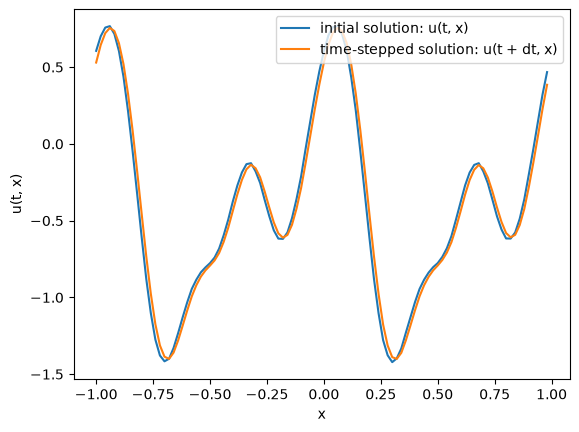

In [204]:
def rk4_step(
    u: Annotated[jax.Array, "(nx,)"],
    dx: float,
    dt: float,
) -> Annotated[jax.Array, "(nx,)"]:
    """
    approximate solution at next time step using 4th order runge-kutta

    parameters
    ----------
    u
        solution
    dx
        grid spacing
    dt
        time step

    returns
    -------
    u_dt
        solution differential between time step
    """
    k1 = rhs(u, dx)
    k2 = rhs(u + k1 * dt / 2, dx)
    k3 = rhs(u + k2 * dt / 2, dx)
    k4 = rhs(u + k3 * dt, dx)
    u_dt = dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return u_dt

# plot time-stepped solution
u_dt = rk4_step(u_0[0], dx, dt)
plt.plot(x, u_0[0], label="initial solution: u(t, x)")
plt.plot(x, u_0[0] + u_dt, label="time-stepped solution: u(t + dt, x)")
plt.xlabel("x")
plt.ylabel("u(t, x)")
plt.legend()
plt.show()

In [205]:
def rk4_evolve(
    u: Annotated[jax.Array, "(nx,)"],
    dx: float,
    dt: float,
) -> Annotated[jax.Array, "(nt, nx)"]:
    """
    evolve approximate solution through time using repeated RK4 steps

    parameters
    ----------
    u
        solution
    dx
        grid spacing
    dt
        time step

    returns
    -------
    trajs
        solution trajectories
    """
    t = min_time 
    trajs = list()
    while t < max_time:
        trajs.append(u)
        u_dt = rk4_step(u, dx, dt)
        u += u_dt
        t += dt
    trajs = jnp.array(trajs)
    return trajs
trajs = rk4_evolve(u_0[0], dx, dt)

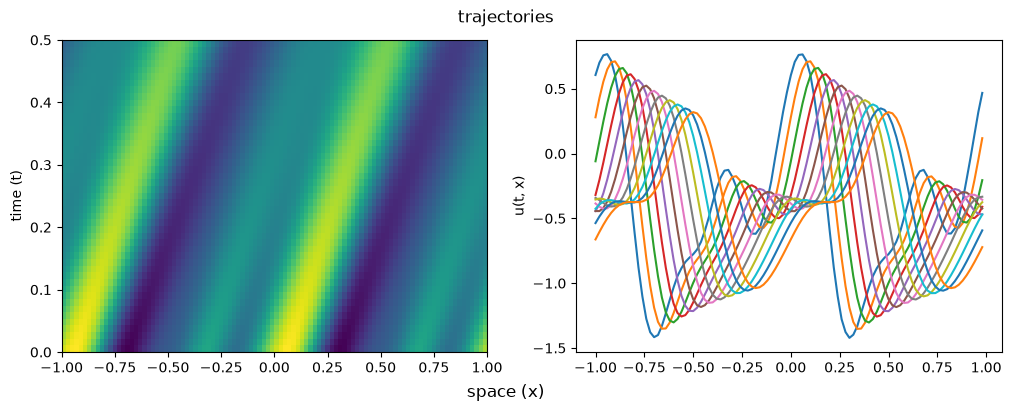

In [206]:
# plot image
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ax[0].imshow(trajs,
        extent=[min_space, max_space, min_time, max_time],
        origin="lower",
        aspect="auto")
ax[0].set_ylabel("time (t)")

# plot curve
for i in range(0, len(trajs), len(trajs) // 10):
    ax[1].plot(x, trajs[i])
ax[1].set_ylabel("u(t, x)")

# configure plot
fig.supxlabel("space (x)")
fig.suptitle("trajectories")
plt.show()

In [207]:
def demonstrate(
    trajs: Annotated[jax.Array, "(nt, nx)"],
    *,
    n: int,
) -> Annotated[jax.Array, "(num_examples, 2, nx)"]:
    """
    create (input, target) examples

    parameters
    ----------
    trajs
        solution trajectories
    n
        number of time steps
    
    returns
    -------
    examples
        input-target examples
    """
    num_exs = len(trajs) - n
    examples = list()
    for i in range(num_exs):
        u_t = trajs[i]
        u_tau = trajs[i + n]
        ex = (u_t, u_tau)
        examples.append(ex)
    examples = jnp.array(examples)
    return examples
examples = demonstrate(trajs, n=30)

In [208]:
def sample_task(
    examples: Annotated[jax.Array, "(num_examples, 2, nx)"],
    key: Annotated[jax.Array, "() | (2,)"],
    *,
    k: int,
) -> tuple[
    Annotated[jax.Array, "(k, 2, nx)"],
    Annotated[jax.Array, "(2, nx)"],
]:
    """
    sample task from examples \\
    task{ \\
    context = examples[0], examples[10], examples[20], examples[30] \\
    query = examples[40] \\
    }

    parameters
    ----------
    examples
        input-target examples
    key
        random number generator
    k
        number of context examples

    returns
    -------
    context
        input-target examples
    query
        held-out input-target example
    """
    # TODO: parameterize the number of query examples
    indices = jr.choice(key, len(examples), shape=(k + 1,), replace=False)
    context = jnp.array([examples[i] for i in indices[:-1]])
    query = jnp.array(examples[indices[-1]])
    return context, query
context, query = sample_task(examples, key, k=4)

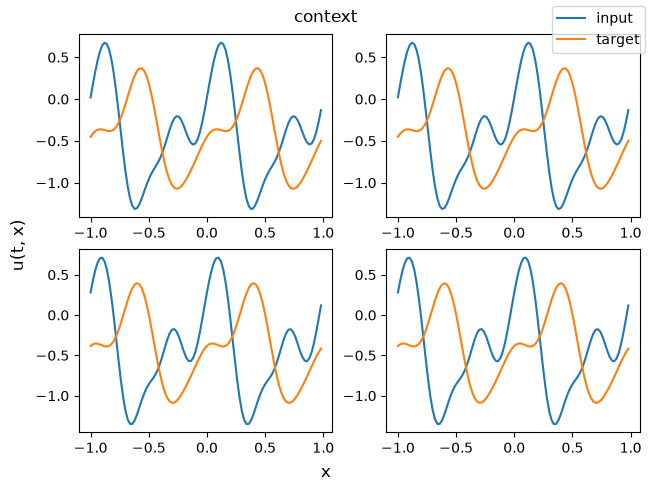

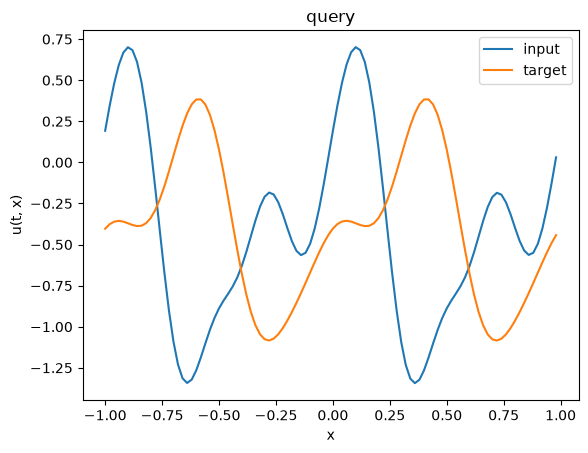

In [215]:
# plot context
fig, ax = plt.subplots(2, 2, constrained_layout=True)
for i in range(2):
    for j in range(2):
        ax[i][j].plot(x, context[i][0], label="input")
        ax[i][j].plot(x, context[i][1], label="target")
fig.supxlabel("x")
fig.supylabel("u(t, x)")
fig.suptitle("context")
handles, labels = ax[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.show()

# plot query
plt.plot(x, query[0], label="input")
plt.plot(x, query[1], label="target")
plt.xlabel("x")
plt.ylabel("u(t, x)")
plt.title("query")
plt.legend()
plt.show()

In [210]:
def tokenize(
    x: Annotated[jax.Array, "(nx,)"],
    context: Annotated[jax.Array, "(k, 2, nx)"],
    query: Annotated[jax.Array, "(2, nx)"],
) -> tuple[
    Annotated[jax.Array, "(num_input_tokens, token_dim)"],
    Annotated[jax.Array, "(num_target_tokens, token_dim)"],
]:
    """
    convert function values into sequence values

    parameters
    ----------
    x
        spatial coordinates
    context
        input-target examples
    query
        held-out input-target example

    returns
    -------
    input_tokens
        sequence of tokenized input function values
    target_tokens
        sequence of tokenized target function values
    """
    input_tokens = list()
    for i in range(context.shape[0]):  # example index
        for j in range(context.shape[1]):  # input-target index
            for k in range(context.shape[2]):  # spatial index
                role = None
                if j == 0:
                    role = 0  # context input
                else:
                    role = 1  # context target
                x_k = x[k]
                tok = (x_k, context[i][j][k], role)
                input_tokens.append(tok)
    target_tokens = list()
    for i in range(len(query)):  # input-target index
        for j in range(len(query[0])):  # spatial index
            x_j = x[j]
            if i == 0:
                role = 2  # query input
                tok = (x_j, query[i][j], role)
                input_tokens.append(tok)
            else:
                role = 3  # query target
                tok = (x_j, query[i][j], role)
                target_tokens.append(tok)
    input_tokens = jnp.array(input_tokens)
    target_tokens = jnp.array(target_tokens)
    return input_tokens, target_tokens
input_tokens, target_tokens = tokenize(x, context, query)

In [211]:
def batch_task(
    x: Annotated[jax.Array, "(nx,)"],
    examples: Annotated[jax.Array, "(num_examples, 2, nx)"],
    key: Annotated[jax.Array, "() | (2,)"],
    *,
    n: int,
    k: int,
) -> tuple[
    Annotated[jax.Array, "(n, num_input_tokens, token_dim)"],
    Annotated[jax.Array, "(n, num_target_tokens, token_dim)"],
]:
    """
    create batch of tokenized tasks

    parameters
    ----------
    x
        spatial coordinates
    examples
        input-target examples
    key
        random number generator
    n
        number of sampled tasks
    k
        number of context examples

    returns
    -------
    input_batch
        sampled input tasks
    target_batch
        sampled target tasks
    """
    input_batch = list()
    target_batch = list()
    for i in range(n):
        key, subkey = jr.split(key)
        context, query = sample_task(examples, subkey, k=k)
        input_tokens, target_tokens = tokenize(x, context, query)
        input_batch.append(input_tokens)
        target_batch.append(target_tokens)
    input_batch = jnp.array(input_batch)
    target_batch = jnp.array(target_batch)
    return input_batch, target_batch
input_batch, target_batch = batch_task(x, examples, key, n=32, k=5)